In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
Ks343 = np.load("FIP35-Ks-343.npy")
Ks27 = np.load("FIP35-Ks.npy")
lag_times = range(1, 101)

In [4]:
ITSs, Es, Vs = [], [], []

for i in range(len(lag_times)):
    evK, vrK = np.linalg.eig(Ks27[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    #print("Time =", lag_times[i], 'ps')
    ITSs.append([-lag_times[i]/np.log(Es[-1][j]) for j in range(1,6)])
    #print(ITSs[-1])
ITS27, Es27, Vs27 = np.array(ITSs).T, Es, Vs

ITSs, Es, Vs = [], [], []
for i in range(len(lag_times)):
    evK, vrK = np.linalg.eig(Ks343[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    #print("Time =", lag_times[i], 'ps')
    ITSs.append([-lag_times[i]/np.log(Es[-1][j]) for j in range(1,6)])
    #print(ITSs[-1])
ITS343, Es343, Vs343 = np.array(ITSs).T, Es, Vs

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

Current date and time: 2026-03-08 23:45:09.594881


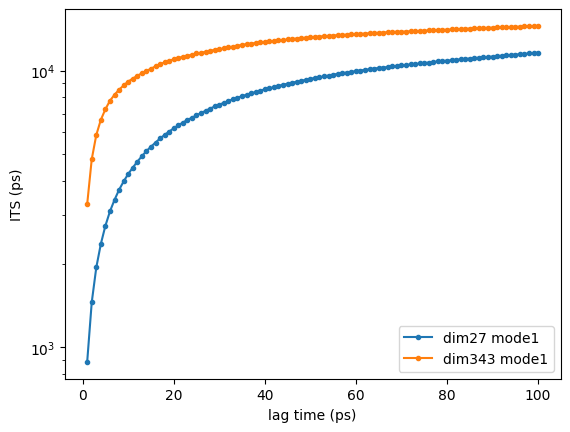

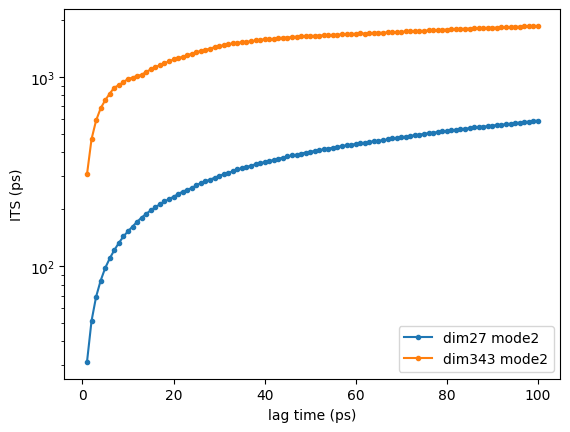

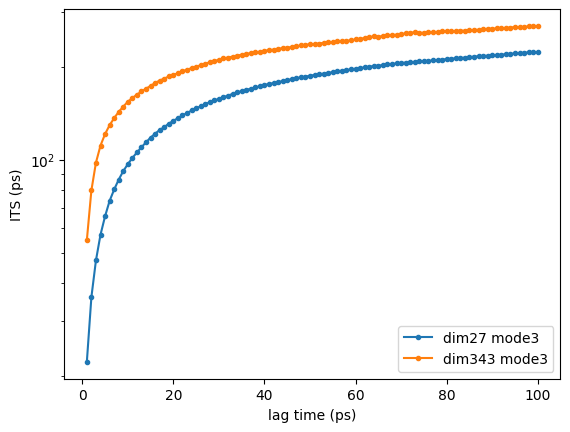

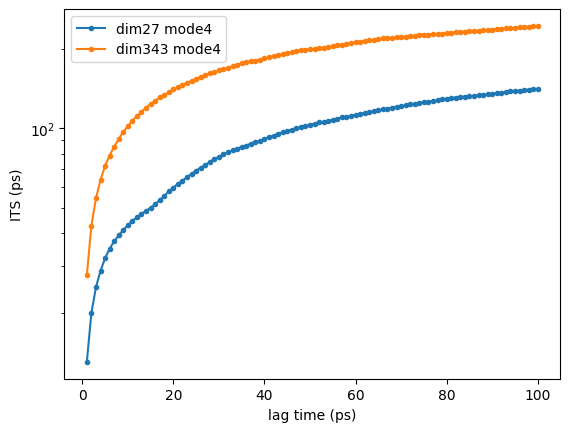

Current date and time: 2026-02-11 10:46:42.301997


In [4]:
for i in range(4):#(ITS.shape[0]):
    fig1, ax1 = plt.subplots()
    ax1.set_yscale('log')
    plt.xlabel("lag time (ps)")
    plt.ylabel("ITS (ps)")
    ax1.plot(lag_times, ITS27[i], '.-', label='dim27 mode'+str(i+1)) 
    ax1.plot(lag_times, ITS343[i], '.-', label='dim343 mode'+str(i+1))
    plt.legend()
    plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

In [5]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


## dim 125 Ks

In [5]:
load_data_from_npz = np.load("FIP35-tICA.npz")
tics_of_trajs = np.concatenate([load_data_from_npz['GTT0'], load_data_from_npz['GTT1']], axis=0)
traj_lens = load_data_from_npz['traj_lens']
print(tics_of_trajs.shape)

(1137344, 3)


In [6]:
basis_list = [[[-0.5402968893832484, 2], [1.6977050721019225, 2], [0.03775098344108225, 2], [-0.11639949878185235, 2]], [[-0.5402968893832484, 2], [1.6977050721019225, 2], [0.03775098344108225, 2], [-0.11639949878185235, 2]], [[-0.5402968893832484, 2], [1.6977050721019225, 2], [0.03775098344108225, 2], [-0.11639949878185235, 2]]]
print(len(basis_list), len(basis_list[0]), len(basis_list[0][0]))
ttica = amuset_tica.AmusetTICA()
svd_v, traj_lens = ttica.build(basis_list, [tics_of_trajs])

3 4 2


Time = 1 frames
Time = 2 frames
Time = 3 frames
Time = 4 frames
Time = 5 frames
Time = 6 frames
Time = 7 frames
Time = 8 frames
Time = 9 frames
Time = 10 frames
Time = 11 frames
Time = 12 frames
Time = 13 frames
Time = 14 frames
Time = 15 frames
Time = 16 frames
Time = 17 frames
Time = 18 frames
Time = 19 frames
Time = 20 frames
Time = 21 frames
Time = 22 frames
Time = 23 frames
Time = 24 frames
Time = 25 frames
Time = 26 frames
Time = 27 frames
Time = 28 frames
Time = 29 frames
Time = 30 frames
Time = 31 frames
Time = 32 frames
Time = 33 frames
Time = 34 frames
Time = 35 frames
Time = 36 frames
Time = 37 frames
Time = 38 frames
Time = 39 frames
Time = 40 frames
ITS.shape = (6, 40)


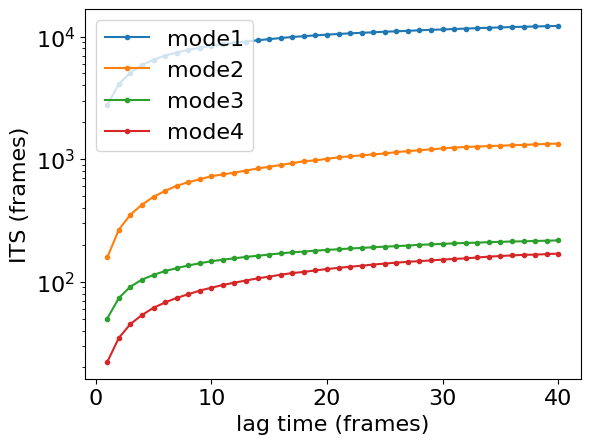

Current date and time: 2026-02-25 20:18:05.175615


In [14]:
ITSs = []
lag_times = list(range(1, 41))
Ks, Es, Vs = [], [], []

for i in lag_times:
    ttica.covariance(svd_v, traj_lens, lag_time=i)
    Ks.append(ttica._K)
    evK, vrK = np.linalg.eig(ttica._K)
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    
    Es.append(evK)
    Vs.append(vrK)
    print("Time =", i, 'frames')
    ITSs.append(ttica.timescales_[:6])
    #print(ITSs[-1])

ITS125, Ks125, Es125, Vs125 = np.array(ITSs).T, Ks, Es, Vs

fig1, ax1 = plt.subplots()
ax1.set_yscale('log')
plt.xlabel("lag time (frames)")
plt.ylabel("ITS (frames)")

print("ITS.shape =", ITS125.shape)
for i in range(4):#(ITS.shape[0]):
    ax1.plot(lag_times, ITS125[i], '.-', label='mode'+str(i+1)) 

plt.legend()
plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

# Comparison: different rank

In [11]:
M_hat_27, _ = fit_M_from_K_sequence(Ks27[:21], 10, 1, enforce_hermitian_M=False)
M_hat_125, _ = fit_M_from_K_sequence(Ks125[:21], 10, 1, enforce_hermitian_M=False)
M_hat_343, _ = fit_M_from_K_sequence(Ks343[:21], 10, 1, enforce_hermitian_M=False)

M_hat_saveRAM = [Ks27[20], M_hat_27, Ks125[20], M_hat_125, Ks343[20], M_hat_343]

ITSs_saveRAM = []
for i in range(len(M_hat_saveRAM)):
    evK, vrK = np.linalg.eig(M_hat_saveRAM[i])
    evK = evK[np.argsort(evK)[::-1]]
    lag_t_mul = 21 if i&1==0 else 1
    if evK[0] - 1 > 1e-5:
        ITSs_saveRAM.append([np.abs(-lag_t_mul/np.log(evK[j])) for j in range(2,7)])
    else:
        ITSs_saveRAM.append([np.abs(-lag_t_mul/np.log(evK[j])) for j in range(1,6)])
    print(ITSs_saveRAM[-1])#

ITSs_saveRAM = np.array(ITSs_saveRAM)
print(ITSs_saveRAM.shape)

[6341.010610690319, 240.38792482026778, 136.3043022115138, 61.63279045858346, 55.65484224239212]
[12891.121920066245, 631.2593437640638, 225.82176183059866, 175.90727083033605, 101.41997673209266]
[10494.60953670085, 1035.9866912479768, 184.1396057541961, 129.78001718821983, 83.11641098461708]
[14494.773688463838, 2060.4517680661343, 287.5295883221189, 261.13325703372834, 216.49329712689095]
[11115.596540044698, 1267.2895899142181, 190.42063312863684, 143.01917558921295, 98.41663473365726]
[14806.545370011654, 2098.375729015161, 303.5046480906723, 276.23933178894816, 208.9649557220201]
(6, 5)


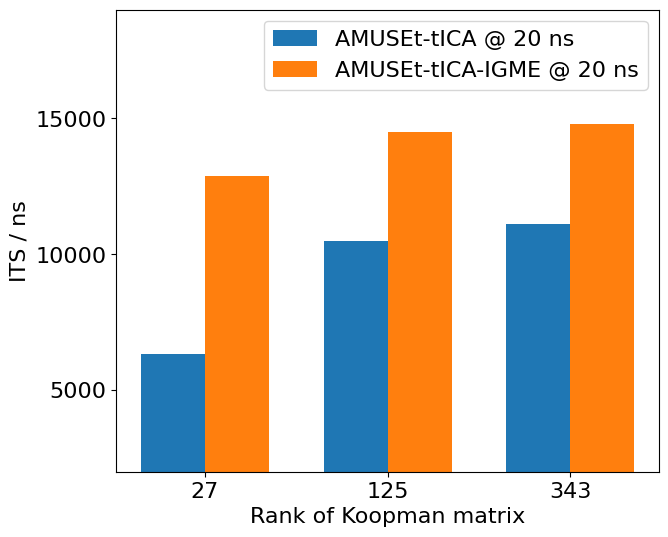

In [12]:
plt.rcParams.update({"font.size": 16})

categories = [27, 125, 343]
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7,6))
#ax.set_yscale('log')
ax.bar(x - width/2, ITSs_saveRAM[0::2, 0], width, label='AMUSEt-tICA @ 20 ns')
ax.bar(x + width/2, ITSs_saveRAM[1::2, 0], width, label='AMUSEt-tICA-IGME @ 20 ns')

plt.xticks(x, categories)
ax.set_xlabel("Rank of Koopman matrix")
ax.set_ylabel("ITS / ns")
ax.set_yticks([5000, 10000, 15000])
ax.set_ylim([2000, 19000])

plt.legend()
plt.show()

In [15]:
ITS27[0], ITS125[0], ITS343[0]

(array([  884.58308078,  1453.42749156,  1942.14445351,  2363.70571177,
         2749.19533582,  3099.03421009,  3410.94196014,  3707.64096837,
         3975.6487932 ,  4228.85641574,  4459.36585975,  4684.7565252 ,
         4905.79036144,  5117.38202573,  5311.1739983 ,  5494.98280329,
         5687.82942636,  5856.11572716,  6025.74739767,  6189.26655633,
         6341.01061069,  6491.44225726,  6633.92669773,  6759.89011515,
         6893.22650287,  7027.17325256,  7161.19557841,  7293.03519647,
         7426.17878447,  7534.25696059,  7651.89513201,  7760.79297652,
         7883.70830516,  7986.32266428,  8086.24163221,  8188.82403033,
         8282.56120626,  8376.65166327,  8472.67440558,  8556.72715521,
         8635.45793966,  8722.6594017 ,  8821.28483851,  8895.01218179,
         8975.93855064,  9054.32715254,  9118.0175082 ,  9196.32457525,
         9270.39501978,  9342.08722149,  9418.21243865,  9468.44394027,
         9537.79684942,  9605.08310396,  9677.03525948,  9739.96

In [16]:
Ks27_high = np.load("FIP35-Ks_lag100-300.npy")
lag_times_high = range(100, 301, 10)

In [17]:

for i in lag_times_high:
    evK, vrK = np.linalg.eig(Ks27_high[i//10-10]) # K[lag]
    evK = evK[np.argsort(evK)[::-1]]
    print('lag', i)#print(evK[:5])
    print([-i/np.log(evK[j]) for j in range(1,6)])

lag 100
[11619.77838680017, 588.8690471894507, 223.00223740432443, 140.70333719704516, 96.93222102238796]
lag 110
[11925.2495338714, 629.6877499770479, 226.91779107252674, 146.03447850774978, 103.11266759260887]
lag 120
[12248.93205874546, 658.6927817700264, 230.89109044349792, 151.4696078441285, 107.3026103045294]
lag 130
[12495.181857949396, 694.6625773806114, 233.59549662291758, 155.97509474728278, 111.63331087808142]
lag 140
[12746.311023490356, 720.8972607472161, 237.29392277688873, 160.27086726432077, 116.33030364813095]
lag 150
[12986.470184085822, 744.7316989211541, 242.04721062801644, 163.90413083695128, 119.45054282087507]
lag 160
[13176.481563303852, 765.9993552987131, 245.1505948102924, 167.8072299352579, 123.4822165820507]
lag 170
[13360.942114355277, 783.5053771496571, 247.5429321176516, 171.70620348509433, 126.57599858879378]
lag 180
[13540.35887794758, 800.9456922885014, 249.1858947055464, 174.33218188492543, 131.19339814117734]
lag 190
[13695.141586797547, 826.24582291

In [21]:
gold_standard = 11849

for i in range(5, 40):
    M_hat_27, _ = fit_M_from_K_sequence(Ks27[:i+11], i, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_27)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = -1/np.log(evK[idx+1])
    print(i, cur_ITS)
    if cur_ITS > gold_standard:
        print('break 27')
        break

for i in range(5, 10):
    M_hat_125, _ = fit_M_from_K_sequence(Ks125[:i+1], i-3, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_125)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = -1/np.log(evK[idx+1])
    print(i, cur_ITS)
    if cur_ITS > gold_standard:
        print('break 125')
        break

for i in range(3, 10):
    M_hat_343, _ = fit_M_from_K_sequence(Ks343[:i+1], i-3, 1, enforce_hermitian_M=False)
    evK, vrK = np.linalg.eig(M_hat_343)
    evK = evK[np.argsort(evK)[::-1]]
    idx = 0
    while evK[idx] - 1 > 1e-5:
        idx += 1
    cur_ITS = -1/np.log(evK[idx+1])
    print(i, cur_ITS)
    if cur_ITS > gold_standard:
        print('break 343')
        break


5 11420.523615071597
6 11830.284940506062
7 12168.13378397297
break 27
5 (11824.599017741297-0j)
6 (12199.374744646091-0j)
break 125
3 (10501.342856445208-0j)
4 (12188.694470533477-0j)
break 343


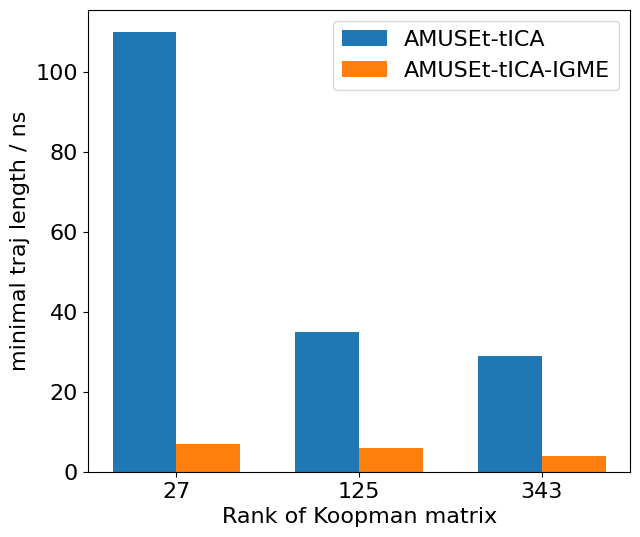

In [5]:
#print('125&343 ITS:', ITS125[0][34], ITS343[0][28])
# limit = 11849 ns
AT_tau_cs = [110, 35, 29]
IGME_tau_cs = [7, 6, 4]

categories = [27, 125, 343]
x = np.arange(len(categories))
width = 0.35

plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(7,6))
ax.bar(x - width/2, AT_tau_cs, width, label='AMUSEt-tICA')
ax.bar(x + width/2, IGME_tau_cs, width, label='AMUSEt-tICA-IGME')

plt.xticks(x, categories)
ax.set_xlabel("Rank of Koopman matrix")
ax.set_ylabel("minimal traj length / ns")

plt.legend()
plt.show()

In [2]:
usage_rank = '''# limit = 11849 ns
AT_tau_cs = [110, 35, 29]
IGME_tau_cs = [7, 6, 4]

categories = [27, 125, 343]
x = np.arange(len(categories))
width = 0.35

plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(7,6))
ax.bar(x - width/2, AT_tau_cs, width, label='AMUSEt-tICA')
ax.bar(x + width/2, IGME_tau_cs, width, label='AMUSEt-tICA-IGME')

plt.xticks(x, categories)
ax.set_xlabel("Rank of Koopman matrix")
ax.set_ylabel("minimal traj length / ns")

plt.legend()
plt.show()'''

np.savez('Panel_2b1_savingRank.npz', title='Saving with rank (RAM)', usage = usage_rank)

In [24]:
load_data = np.load('Panel_2b1_savingRank.npz')
print(load_data['usage'])

# limit = 11849 ns
AT_tau_cs = [110, 35, 29]
IGME_tau_cs = [7, 6, 4]

categories = [27, 125, 343]
x = np.arange(len(categories))
width = 0.35

plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(7,6))
ax.bar(x - width/2, AT_tau_cs, width, label='AMUSEt-tICA')
ax.bar(x + width/2, IGME_tau_cs, width, label='AMUSEt-tICA-IGME')

plt.xticks(x, categories)
ax.set_xlabel("Rank of Koopman matrix")
ax.set_ylabel("tau_coherence / ns")

plt.legend()
plt.show()


# ITS @ lag_times

In [7]:
K_hat_collect = []
M_hat, _ = fit_M_from_K_sequence(Ks27[:11], 5, 1, enforce_hermitian_M=False)
K_hat_collect.append(M_hat)

for i in range(1, 10):
    M_hat, _ = fit_M_from_K_sequence(Ks27[:i*10+10], i*10-1, 1, enforce_hermitian_M=False)
    K_hat_collect.append(M_hat)

In [8]:
ITSs_Khat = []
for i in range(len(K_hat_collect)):
    evK, vrK = np.linalg.eig(K_hat_collect[i])
    idx = np.argsort(evK)[::-1]
    evK = evK[idx]
    vrK = vrK[:,idx]
    if evK[0] - 1 > 1e-5:
        ITSs_Khat.append([np.abs(-1/np.log(evK[j])) for j in range(2,7)])
    else:
        ITSs_Khat.append([np.abs(-1/np.log(evK[j])) for j in range(1,6)])
    print(ITSs_Khat[-1])#

ITS_Khat = np.array(ITSs_Khat).T
print(ITS_Khat.shape)

[10688.128351186046, 419.8971440741991, 186.0197746696176, 109.86650311589797, 73.28754437995607]
[12580.668264231796, 588.336930854806, 220.03570798460933, 163.1570028634483, 93.77151621784292]
[15252.037541989357, 919.0909324424209, 287.30961599563966, 218.68154033975736, 157.70978506211188]
[15980.054170222766, 1233.6192327797953, 467.0799492790676, 279.8188273618984, 197.37074862861664]
[15589.195041978275, 977.0986258383912, 348.0662007407189, 230.1609416007235, 193.353114290119]
[16925.364503665463, 1125.5266429723195, 519.0987430394999, 308.2404215608068, 231.06330235509742]
[16080.119330072434, 4744.045600913838, 1071.3712036613558, 449.23672593281856, 338.11531240966684]
[17101.47304087486, 1638.399193957542, 400.96139103062296, 287.2750689897106, 221.8312545841659]
[18612.25006519735, 3785.512505312795, 435.422701632536, 435.422701632536, 339.5539818488577]
[20297.43953849161, 2036.8875808621788, 2036.8875808621788, 879.4695733913871, 429.5645558531456]
(5, 10)


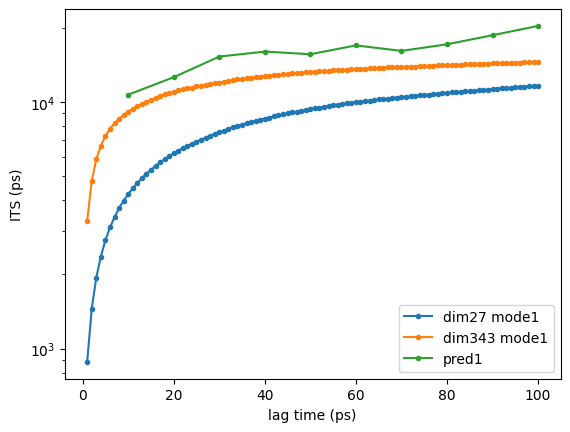

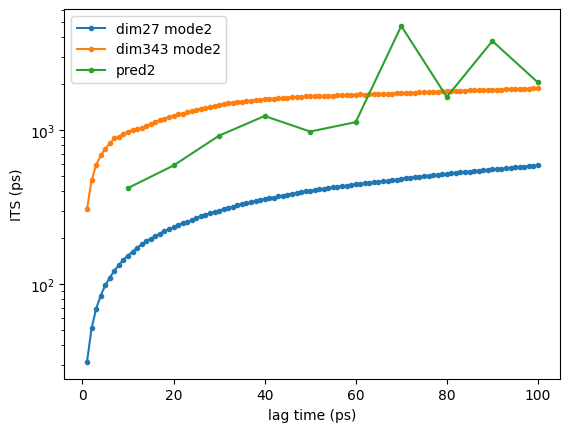

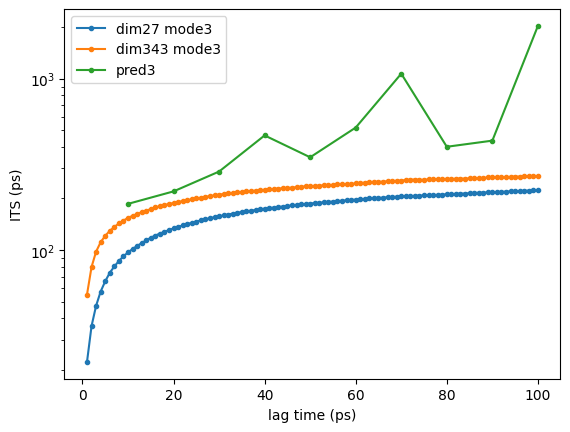

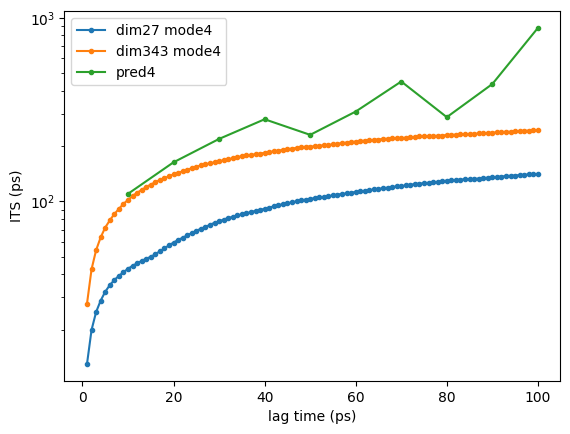

Current date and time: 2026-02-11 14:46:04.944684


In [38]:
for i in range(4):#(ITS.shape[0]):
    fig1, ax1 = plt.subplots()
    ax1.set_yscale('log')
    plt.xlabel("lag time (ps)")
    plt.ylabel("ITS (ps)")
    ax1.plot(lag_times, ITS27[i], '.-', label='dim27 mode'+str(i+1)) 
    ax1.plot(lag_times, ITS343[i], '.-', label='dim343 mode'+str(i+1))
    ax1.plot(range(10, 101, 10), ITS_Khat[i], '.-', label='pred'+str(i+1))
    plt.legend()
    plt.show()

from datetime import datetime
print(f"Current date and time: {datetime.now()}")

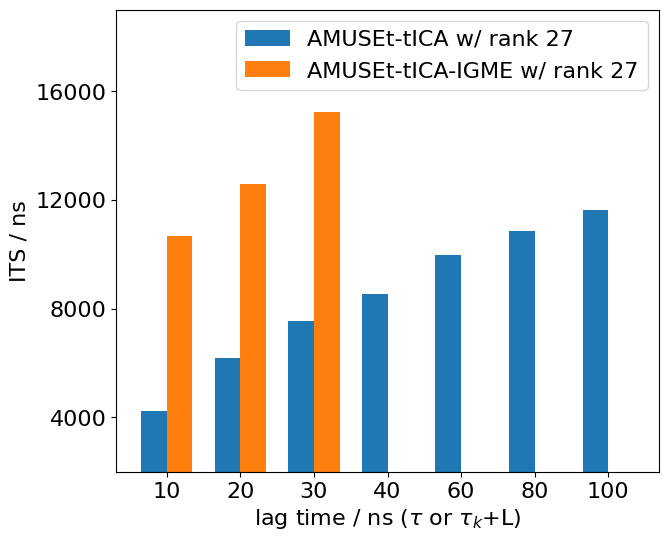

In [30]:

categories = list(range(10, 41, 10)) + [60, 80, 100]
group1 = list(ITS27[0][9:41:10]) + list(ITS27[0][59:101:20])
group2 = list(ITS_Khat[0][:3]) + [0, 0, 0, 0]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize = (7,6))
#ax.set_yscale('log')
ax.bar(x - width/2, group1, width, label='AMUSEt-tICA w/ rank 27')
ax.bar(x + width/2, group2, width, label='AMUSEt-tICA-IGME w/ rank 27')

plt.xticks(x, categories)
ax.set_xlabel(r"lag time / ns ($\tau$ or $\tau_k$+L)")
ax.set_ylabel("ITS / ns")
plt.ylim([2000, 19000])
plt.yticks([4000, 8000, 12000, 16000])

plt.legend()
plt.show()


In [3]:
Ks27_high = np.load("FIP35-Ks_lag100-300.npy")
lag_times_high = range(100, 301, 10)

In [22]:
categories = list(range(10, 51, 20)) + [100, 200, 300]
group1 = list(ITS27[0][9:51:20])
group2 = list(ITS_Khat[0][:5:2])

for i in [100, 200, 300]:
    evK, vrK = np.linalg.eig(Ks27_high[i//10-10]) # K[lag]
    evK = evK[np.argsort(evK)[::-1]]
    print(evK[:5])
    group1.append(-i/np.log(evK[1]))
    
    group2.append(0)

print(group1)
print(group2)

[1.         0.99143091 0.84381919 0.63863257 0.4912927 ]
[1.         0.98567833 0.78841659 0.44889483 0.32908929]
[1.         0.98022974 0.73667584 0.31186872 0.23011041]
[4228.856415737327, 7534.256960590483, 9342.087221486794, 11619.77838680017, 13864.607607134203, 15023.809588373926]
[10688.128351186046, 15252.037541989357, 15589.195041978275, 0, 0, 0]


In [15]:
#categories, group1, group2 = data[0], data[1], data[2]

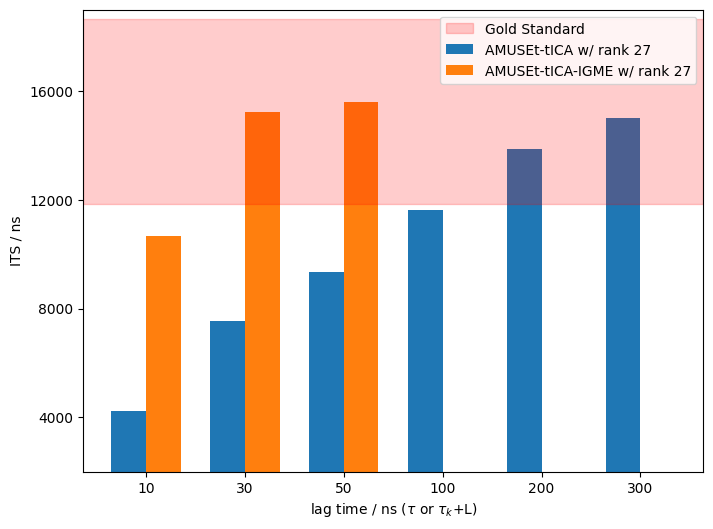

In [23]:
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize = (8,6))
#ax.set_yscale('log')
ax.bar(x - width/2, group1, width, label='AMUSEt-tICA w/ rank 27')
ax.bar(x + width/2, group2, width, label='AMUSEt-tICA-IGME w/ rank 27')
y_min, y_max = 18670.1, 11849.1
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.xticks(x, categories)
ax.set_xlabel(r"lag time / ns ($\tau$ or $\tau_k$+L)")
ax.set_ylabel("ITS / ns")
plt.ylim([2000, 19000])
plt.yticks([4000, 8000, 12000, 16000])

plt.legend()
plt.show()

In [24]:
combine_data = np.array([categories, group1, group2])
usage_tau = '''x = np.arange(len(data[0]))
width = 0.35

fig, ax = plt.subplots(figsize = (8,6))
#ax.set_yscale('log')
ax.bar(x - width/2, data[1], width, label='AMUSEt-tICA w/ rank 27')
ax.bar(x + width/2, data[2], width, label='AMUSEt-tICA-IGME w/ rank 27')

y_min, y_max = 18670.1, 11849.1
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.xticks(x, data[0])
ax.set_xlabel(r"lag time / ns ($\\tau$ or $\\tau_k$+L)")
ax.set_ylabel("ITS / ns")
plt.ylim([2000, 17000])
plt.yticks([4000, 8000, 12000, 16000])

plt.legend()
plt.show()'''

In [25]:
np.savez('Panel_2b2_savingLagT.npz', title='Saving with lag time', data=combine_data, usage = usage_tau)

In [26]:
load_data = np.load('Panel_2b2_savingLagT.npz')
print(load_data['usage'])
data = load_data['data']

x = np.arange(len(data[0]))
width = 0.35

fig, ax = plt.subplots(figsize = (8,6))
#ax.set_yscale('log')
ax.bar(x - width/2, data[1], width, label='AMUSEt-tICA w/ rank 27')
ax.bar(x + width/2, data[2], width, label='AMUSEt-tICA-IGME w/ rank 27')

y_min, y_max = 18670.1, 11849.1
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.xticks(x, data[0])
ax.set_xlabel(r"lag time / ns ($\tau$ or $\tau_k$+L)")
ax.set_ylabel("ITS / ns")
plt.ylim([2000, 17000])
plt.yticks([4000, 8000, 12000, 16000])

plt.legend()
plt.show()


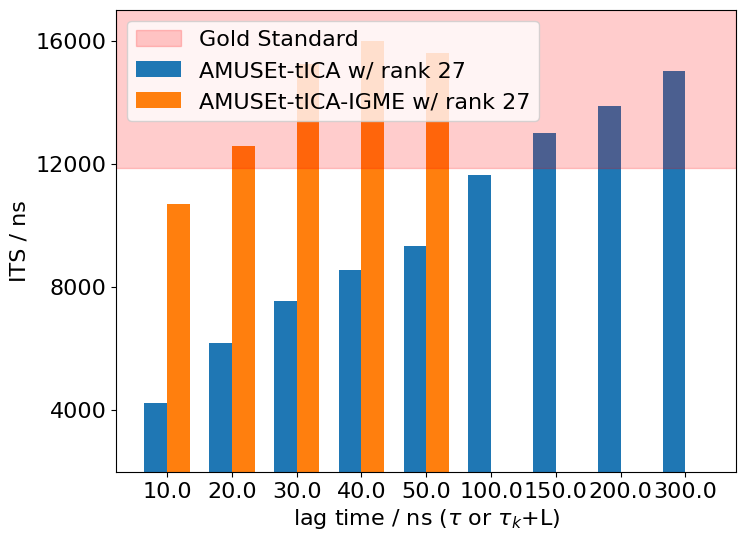

In [19]:
x = np.arange(len(data[0]))
width = 0.35

fig, ax = plt.subplots(figsize = (8,6))
#ax.set_yscale('log')
ax.bar(x - width/2, data[1], width, label='AMUSEt-tICA w/ rank 27')
ax.bar(x + width/2, data[2], width, label='AMUSEt-tICA-IGME w/ rank 27')

y_min, y_max = 18670.1, 11849.1
plt.axhspan(y_min, y_max, color='red', alpha=0.2, label='Gold Standard')

plt.xticks(x, data[0])
ax.set_xlabel(r"lag time / ns ($\tau$ or $\tau_k$+L)")
ax.set_ylabel("ITS / ns")
plt.ylim([2000, 17000])
plt.yticks([4000, 8000, 12000, 16000])

plt.legend()
plt.show()